In [1]:
# ============================================================
# PHASE — LIGHTWEIGHT EXPLAINABILITY + TEMPORAL ANALYSIS
# Replaces SHAP (too slow on laptop)
# ============================================================
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

with open('phase3_checkpoint.pkl', 'rb') as f:
    p3 = pickle.load(f)

df              = p3['df']
trip_agg        = p3['trip_agg']
best_rf         = p3['best_rf']
baseline_features = p3['baseline_features']
THRESHOLD_SEVERE  = p3['THRESHOLD_SEVERE']

y = trip_agg['total_actual_time']

from sklearn.model_selection import train_test_split
X_c = trip_agg[baseline_features].fillna(0)
X_c_train, X_c_test, y_train, y_test = train_test_split(
    X_c, y, test_size=0.2, random_state=42,
    stratify=trip_agg['route_type']
)

print("✅ Loaded")

✅ Loaded


In [2]:
# ── PART 1: RF Feature Importance (fast) ─────────────────────
fi_df = pd.DataFrame({
    'feature':    baseline_features,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== RF FEATURE IMPORTANCE (impurity-based) ===")
print(fi_df.to_string(index=False))


=== RF FEATURE IMPORTANCE (impurity-based) ===
              feature  importance
    log_osrm_distance    0.532553
        log_osrm_time    0.262576
       total_segments    0.115813
   log_total_distance    0.037061
mean_speed_efficiency    0.010811
      is_complex_trip    0.010449
  pct_severe_segments    0.008179
 distance_per_segment    0.007298
osrm_time_per_segment    0.003765
    severe_x_segments    0.003526
       src_state_freq    0.001530
       dst_state_freq    0.001110
     time_per_km_osrm    0.001076
           osrm_speed    0.001075
        creation_hour    0.000858
       src_ftype_freq    0.000741
       dst_ftype_freq    0.000528
        is_interstate    0.000461
       route_type_enc    0.000409
           is_weekend    0.000101
       creation_month    0.000054
   carting_intrastate    0.000029


In [3]:
# ── PART 2: Permutation Importance (already computed in P3) ──
# Recompute quickly on test set — 5 repeats only (fast)
print("\nComputing permutation importance (5 repeats, ~2 min)...")
perm = permutation_importance(
    best_rf, X_c_test, y_test,
    n_repeats=5, random_state=42,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
perm_df = pd.DataFrame({
    'feature':   baseline_features,
    'perm_imp':  perm.importances_mean,
    'perm_std':  perm.importances_std,
    'rf_imp':    best_rf.feature_importances_
}).sort_values('perm_imp', ascending=False)

print("\n=== PERMUTATION vs RF IMPORTANCE (disagreements = interesting) ===")
print(perm_df.round(4).to_string(index=False))

# Features where RF importance and permutation importance disagree
perm_df['rank_rf']   = perm_df['rf_imp'].rank(ascending=False)
perm_df['rank_perm'] = perm_df['perm_imp'].rank(ascending=False)
perm_df['rank_diff'] = abs(perm_df['rank_rf'] - perm_df['rank_perm'])
print("\nFeatures with large rank disagreement (possible collinearity):")
print(perm_df[perm_df['rank_diff'] > 5][
    ['feature','rank_rf','rank_perm','rank_diff']
].to_string())


Computing permutation importance (5 repeats, ~2 min)...

=== PERMUTATION vs RF IMPORTANCE (disagreements = interesting) ===
              feature  perm_imp  perm_std  rf_imp
    log_osrm_distance  219.5312    3.7198  0.5326
        log_osrm_time  110.9186    2.3054  0.2626
mean_speed_efficiency   29.5009    1.0909  0.0108
       total_segments   25.0051    0.5771  0.1158
  pct_severe_segments   11.3151    0.3313  0.0082
   log_total_distance    6.1821    0.2665  0.0371
    severe_x_segments    3.8024    0.1212  0.0035
 distance_per_segment    2.6523    0.2421  0.0073
osrm_time_per_segment    2.0182    0.1715  0.0038
       src_state_freq    1.1048    0.2446  0.0015
           osrm_speed    1.0551    0.0900  0.0011
     time_per_km_osrm    1.0548    0.0875  0.0011
       src_ftype_freq    0.6116    0.1027  0.0007
       dst_state_freq    0.5861    0.0941  0.0011
        creation_hour    0.4878    0.0986  0.0009
      is_complex_trip    0.3204    0.0784  0.0104
       dst_ftype_freq    

In [4]:
# ── PART 3: Temporal Feature Engineering ─────────────────────
# Your instinct was right — Sunday 2am != Monday 2am
# Hour alone is insufficient. Need: hour × dayofweek interaction

print("\n\n=== TEMPORAL ANALYSIS ===")

# Segment-level temporal delay patterns
df['hour_dow'] = df['creation_hour'].astype(str) + '_' + df['creation_dayofweek'].astype(str)

# Peak vs off-peak definition
# Peak hours: 9-12 (morning dispatch), 14-18 (afternoon), 20-23 (night batch)
df['is_peak_morning']  = df['creation_hour'].between(9, 12).astype(int)
df['is_peak_afternoon']= df['creation_hour'].between(14, 18).astype(int)
df['is_peak_night']    = df['creation_hour'].between(20, 23).astype(int)
df['is_peak']          = (
    df['is_peak_morning'] | df['is_peak_afternoon'] | df['is_peak_night']
).astype(int)

# Delay by hour × day_of_week
hourly_dow = df.groupby(['creation_hour','creation_dayofweek'])['delay_ratio'].agg(
    median='median', mean='mean', count='count'
).reset_index()

print("Peak vs off-peak delay:")
print(df.groupby('is_peak')['delay_ratio'].agg(['median','mean','count']).round(3))

print("\nWorst hour-day combinations (median delay):")
print(hourly_dow.nlargest(10,'median')[
    ['creation_hour','creation_dayofweek','median','count']
].rename(columns={'creation_dayofweek':'day_0Mon_6Sun'}).to_string())

print("\nBest hour-day combinations (median delay):")
print(hourly_dow.nsmallest(10,'median')[
    ['creation_hour','creation_dayofweek','median','count']
].rename(columns={'creation_dayofweek':'day_0Mon_6Sun'}).to_string())

# Monthly seasonality
monthly = df.groupby('creation_month')['delay_ratio'].agg(['median','count']).reset_index()
print("\nDelay by month:")
print(monthly.to_string())



=== TEMPORAL ANALYSIS ===
Peak vs off-peak delay:
         median   mean  count
is_peak                      
0         1.713  2.102  65860
1         1.684  2.049  75801

Worst hour-day combinations (median delay):
    creation_hour  day_0Mon_6Sun    median  count
54              7              5  1.916667    305
25              3              4  1.909091    611
23              3              2  1.900000    720
24              3              3  1.900000    743
81             11              4  1.900000    331
21              3              0  1.875000    617
79             11              2  1.871711    590
26              3              5  1.857143    717
77             11              0  1.857143    301
87             12              3  1.846154    220

Best hour-day combinations (median delay):
     creation_hour  day_0Mon_6Sun    median  count
88              12              4  1.533333    384
136             19              3  1.588235   1540
143             20              3  1

In [5]:
# ── PART 4: Add Temporal Features to trip_agg ────────────────
# Hour × dayofweek interaction (cyclic encoding)
trip_agg['hour_sin']   = np.sin(2*np.pi*trip_agg['creation_hour']/24)
trip_agg['hour_cos']   = np.cos(2*np.pi*trip_agg['creation_hour']/24)
trip_agg['dow_sin']    = np.sin(2*np.pi*trip_agg['creation_dayofweek']/7)
trip_agg['dow_cos']    = np.cos(2*np.pi*trip_agg['creation_dayofweek']/7)

# Peak flags
trip_agg['is_peak_morning']   = trip_agg['creation_hour'].between(9,12).astype(int)
trip_agg['is_peak_afternoon']  = trip_agg['creation_hour'].between(14,18).astype(int)
trip_agg['is_peak_night']      = trip_agg['creation_hour'].between(20,23).astype(int)

# Hour × route_type interaction
# FTL at 3am (night batch) behaves very differently from FTL at 10am
trip_agg['ftl_night_batch'] = (
    (trip_agg['route_type_enc']==1) &
    (trip_agg['creation_hour'].between(0,5))
).astype(int)

trip_agg['carting_peak'] = (
    (trip_agg['route_type_enc']==0) &
    (trip_agg['creation_hour'].between(9,18))
).astype(int)

# Month-based seasonality (festival season = Oct-Nov in India)
trip_agg['is_festive_season'] = trip_agg['creation_month'].isin([10,11]).astype(int)

new_temporal = [
    'hour_sin','hour_cos','dow_sin','dow_cos',
    'is_peak_morning','is_peak_afternoon','is_peak_night',
    'ftl_night_batch','carting_peak','is_festive_season'
]
print(f"\nNew temporal features added: {new_temporal}")


New temporal features added: ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_peak_morning', 'is_peak_afternoon', 'is_peak_night', 'ftl_night_batch', 'carting_peak', 'is_festive_season']


In [6]:
# ── PART 5: Retrain with Temporal Features ───────────────────
from sklearn.ensemble import RandomForestRegressor

SET_TEMPORAL = baseline_features + new_temporal
X_t = trip_agg[SET_TEMPORAL].fillna(0)

X_t_train, X_t_test, y_t_train, y_t_test = train_test_split(
    X_t, y, test_size=0.2, random_state=42,
    stratify=trip_agg['route_type']
)

rf_temporal = RandomForestRegressor(
    n_estimators=500, max_depth=None,
    min_samples_leaf=3, min_samples_split=5,
    max_features=0.6, random_state=42, n_jobs=-1
)
rf_temporal.fit(X_t_train, y_t_train)
pred_temporal = rf_temporal.predict(X_t_test)

mae_temporal   = mean_absolute_error(y_t_test, pred_temporal)
within_temporal= np.mean(np.abs(y_t_test-pred_temporal)/np.abs(y_t_test) < 0.15)
baseline_mae   = p3['baseline_mae']
baseline_w15   = p3['baseline_within15']

print("\n=== TEMPORAL FEATURES IMPACT ===")
print(f"Baseline RF (Set C):         MAE={baseline_mae:.2f}  within-15%={baseline_w15:.1%}")
print(f"+ Temporal features:         MAE={mae_temporal:.2f}  within-15%={within_temporal:.1%}")
print(f"Improvement:                 {baseline_mae-mae_temporal:+.2f} min  "
      f"{within_temporal-baseline_w15:+.1%}")

# Temporal feature importances
fi_temporal = pd.DataFrame({
    'feature':    SET_TEMPORAL,
    'importance': rf_temporal.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTemporal feature importances (new features only):")
print(fi_temporal[fi_temporal['feature'].isin(new_temporal)].to_string(index=False))


=== TEMPORAL FEATURES IMPACT ===
Baseline RF (Set C):         MAE=30.95  within-15%=77.6%
+ Temporal features:         MAE=31.03  within-15%=77.8%
Improvement:                 -0.08 min  +0.2%

Temporal feature importances (new features only):
          feature  importance
         hour_sin    0.000965
         hour_cos    0.000581
          dow_sin    0.000308
          dow_cos    0.000197
  ftl_night_batch    0.000080
    is_peak_night    0.000060
is_peak_afternoon    0.000050
  is_peak_morning    0.000035
is_festive_season    0.000033
     carting_peak    0.000019



Plot saved: temporal_explainability.png


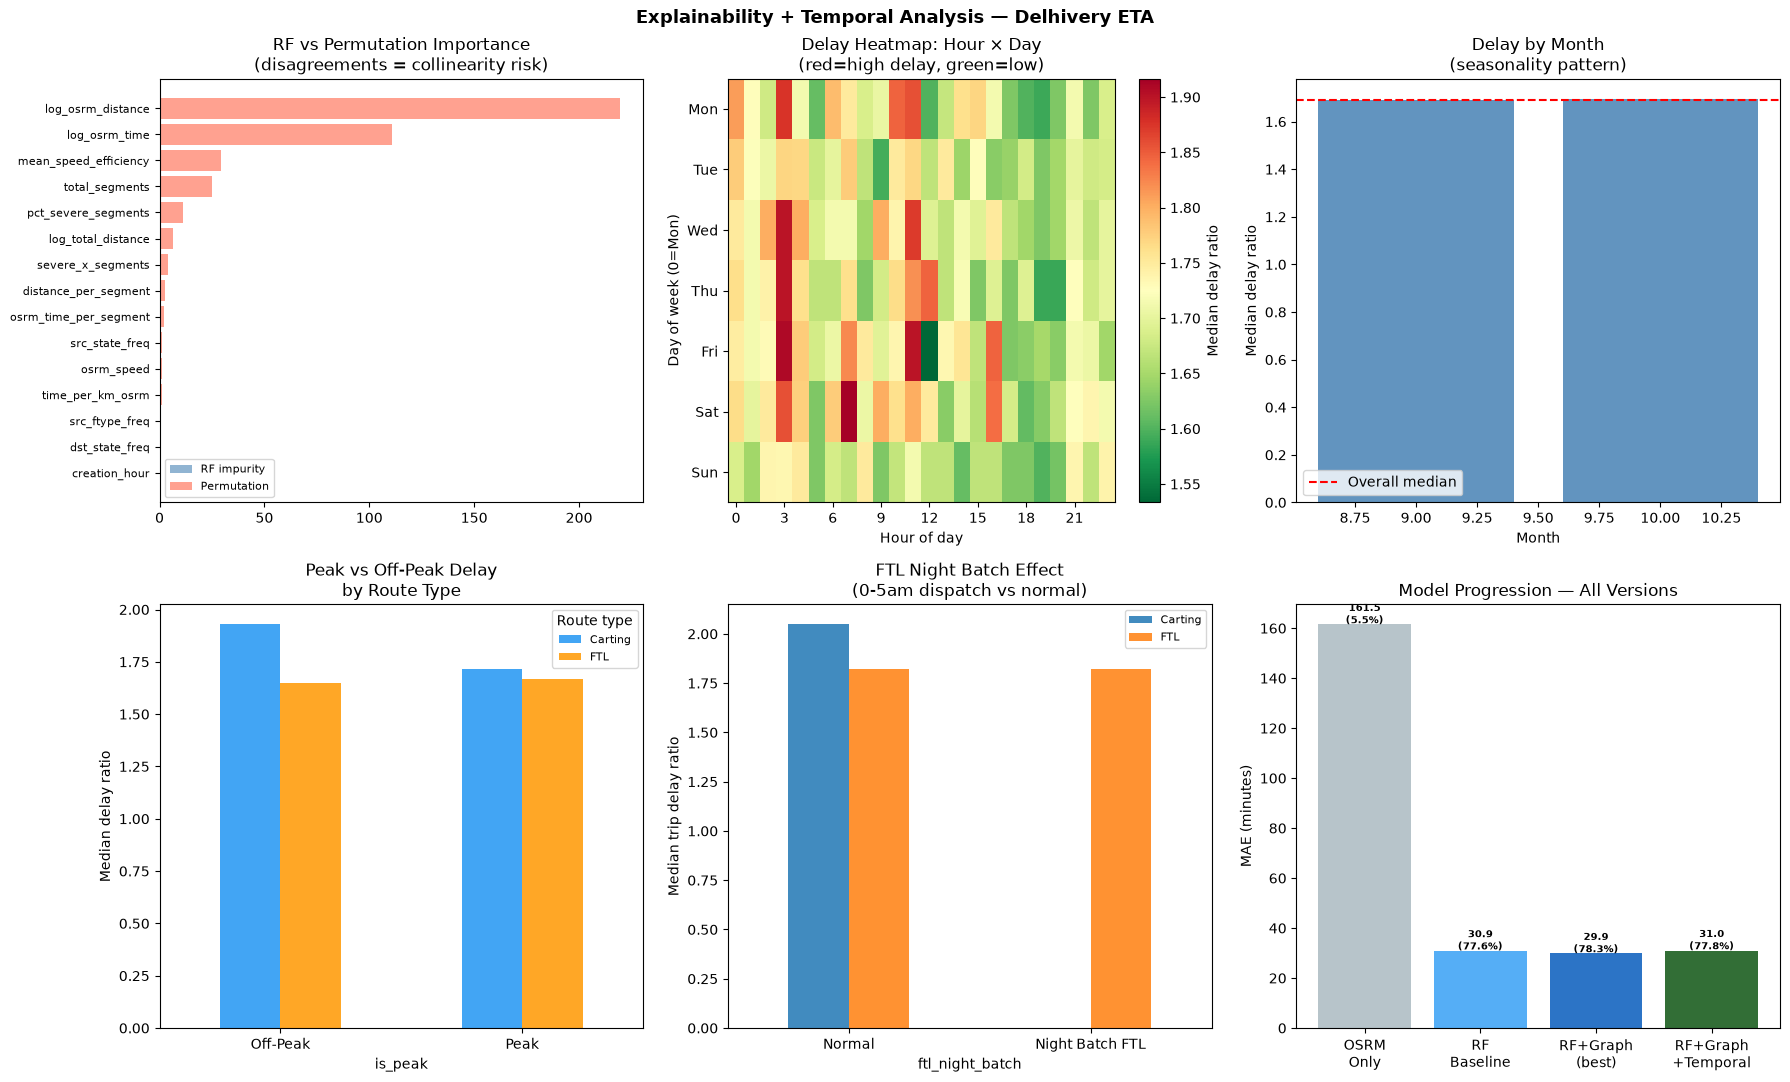


=== FINAL MODEL SUMMARY ===
OSRM only:          MAE=161.5  within-15%=5.5%
RF baseline:        MAE=30.95  within-15%=77.6%
RF+Graph:           MAE=29.85  within-15%=78.3%
RF+Graph+Temporal:  MAE=31.03  within-15%=77.8%


In [7]:

# ── PART 6: Visualizations ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1. Feature importance comparison (RF vs Permutation)
top15 = perm_df.head(15)
axes[0,0].barh(range(len(top15)), top15['rf_imp'].values,
               alpha=0.6, color='steelblue', label='RF impurity')
axes[0,0].barh(range(len(top15)), top15['perm_imp'].values,
               alpha=0.6, color='tomato', label='Permutation')
axes[0,0].set_yticks(range(len(top15)))
axes[0,0].set_yticklabels(top15['feature'].values, fontsize=8)
axes[0,0].set_title('RF vs Permutation Importance\n(disagreements = collinearity risk)')
axes[0,0].legend(fontsize=8)
axes[0,0].invert_yaxis()

# 2. Delay heatmap — hour × day of week
pivot = hourly_dow.pivot(index='creation_dayofweek',
                          columns='creation_hour',
                          values='median').fillna(hourly_dow['median'].mean())
im = axes[0,1].imshow(pivot.values, cmap='RdYlGn_r', aspect='auto')
plt.colorbar(im, ax=axes[0,1], label='Median delay ratio')
axes[0,1].set_xlabel('Hour of day')
axes[0,1].set_ylabel('Day of week (0=Mon)')
axes[0,1].set_title('Delay Heatmap: Hour × Day\n(red=high delay, green=low)')
axes[0,1].set_xticks(range(0,24,3))
axes[0,1].set_xticklabels(range(0,24,3))
axes[0,1].set_yticks(range(7))
axes[0,1].set_yticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])

# 3. Monthly seasonality
axes[0,2].bar(monthly['creation_month'], monthly['median'],
              color='steelblue', alpha=0.85)
axes[0,2].set_xlabel('Month')
axes[0,2].set_ylabel('Median delay ratio')
axes[0,2].set_title('Delay by Month\n(seasonality pattern)')
axes[0,2].axhline(df['delay_ratio'].median(), color='red',
                   linestyle='--', lw=1.5, label='Overall median')
axes[0,2].legend()

# 4. Peak vs off-peak by route type
peak_rt = df.groupby(['is_peak','route_type'])['delay_ratio'].median().unstack()
peak_rt.plot(kind='bar', ax=axes[1,0], color=['#2196F3','#FF9800'], alpha=0.85)
axes[1,0].set_xticklabels(['Off-Peak','Peak'], rotation=0)
axes[1,0].set_ylabel('Median delay ratio')
axes[1,0].set_title('Peak vs Off-Peak Delay\nby Route Type')
axes[1,0].legend(title='Route type', fontsize=8)

# 5. FTL night batch effect
if 'ftl_night_batch' in trip_agg.columns:
    nb_effect = trip_agg.groupby(['ftl_night_batch','route_type'])['trip_delay_ratio'].median().unstack()
    nb_effect.plot(kind='bar', ax=axes[1,1], alpha=0.85)
    axes[1,1].set_xticklabels(['Normal','Night Batch FTL'], rotation=0)
    axes[1,1].set_ylabel('Median trip delay ratio')
    axes[1,1].set_title('FTL Night Batch Effect\n(0-5am dispatch vs normal)')
    axes[1,1].legend(fontsize=8)

# 6. Model comparison final
all_maes = [161.5, 30.95, 29.85, mae_temporal]
all_w15  = [0.055, 0.776, 0.783, within_temporal]
labels   = ['OSRM\nOnly', 'RF\nBaseline', 'RF+Graph\n(best)', 'RF+Graph\n+Temporal']
colors   = ['#B0BEC5','#42A5F5','#1565C0','#1B5E20']
bars = axes[1,2].bar(labels, all_maes, color=colors, alpha=0.9)
axes[1,2].set_ylabel('MAE (minutes)')
axes[1,2].set_title('Model Progression — All Versions')
for bar, val, w in zip(bars, all_maes, all_w15):
    axes[1,2].text(bar.get_x()+bar.get_width()/2,
                   bar.get_height()+0.5,
                   f'{val:.1f}\n({w:.1%})',
                   ha='center', fontsize=7, fontweight='bold')

plt.suptitle('Explainability + Temporal Analysis — Delhivery ETA',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('temporal_explainability.png', dpi=150, bbox_inches='tight')
print("\nPlot saved: temporal_explainability.png")
plt.show()

print("\n=== FINAL MODEL SUMMARY ===")
print(f"OSRM only:          MAE=161.5  within-15%=5.5%")
print(f"RF baseline:        MAE={baseline_mae:.2f}  within-15%={baseline_w15:.1%}")
print(f"RF+Graph:           MAE=29.85  within-15%=78.3%")
print(f"RF+Graph+Temporal:  MAE={mae_temporal:.2f}  within-15%={within_temporal:.1%}")